In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
from PF2nlfff.packages import *
from PF2nlfff.model_3D import *
from PF2nlfff.tools import *
from PF2nlfff.nlfff_module import *
import scipy

In [5]:
bcube = scipy.io.loadmat('../Low_Lou/Bxyz.mat')['Expression1']
bcube = bcube.transpose(3,0,1,2)
boundary = bcube[:,:,:,0]
LL_PF = np.load('../Low_Lou/LL_PF.npy')
LL_data = adc_shape(bcube,is_print_info=False)
PF_data = adc_shape(LL_PF,is_print_info=False)

In [6]:
gan_model = torch.load('GAN_models/best_model.pkl')
import copy
netG = copy.deepcopy(gan_model.netG)
model = PICNN(PF_data, net=netG, device=torch.device('cuda:1'))
PF_tensor = torch.from_numpy(PF_data).unsqueeze(0).cuda()
model.net.eval()
with torch.no_grad():
    gen_data = gan_model.netG(PF_tensor)[0].detach().cpu().numpy()
Bcube2vtr(gen_data, savepath='LL_generated_data')

In [27]:
model.L_ff  = 1.e-3
model.L_div = 1.e-2
model.L_bc  = 1.e4
model.L_Sj  = 1.e1
model.L_fi  = 1.e3
model.L_lf  = 1.e-2
model.print_epoch=100
model.save_epoch=5000
model._use_mf = True
LR = 1.e-3
step_size = 40
gamma=0.99
model.train(10001, lr=LR, Delta=step_size, gamma=gamma, save_best=True, save_first=False,
            save_model_dir='./trainer/L2_model', save_model_name='retrained_L2'
           )

Iter 00000, Loss: 1.766e+05, Loss_div: 2.374e+04,Loss_ff: 9.685e+03, Loss_bc: 1.410e+05, Loss_lf: 2.022e+03, wall_time: 3.978e-01 sec, lr: 1.000e-03
Iter 00100, Loss: 2.540e+03, Loss_div: 9.269e+01,Loss_ff: 1.696e+02, Loss_bc: 2.213e+03, Loss_lf: 1.419e+01, wall_time: 5.072e+01 sec, lr: 9.510e-04
Iter 00200, Loss: 4.508e+03, Loss_div: 7.281e+01,Loss_ff: 6.914e+01, Loss_bc: 4.321e+03, Loss_lf: 7.051e+00, wall_time: 1.010e+02 sec, lr: 9.044e-04
Iter 00300, Loss: 6.911e+03, Loss_div: 4.116e+01,Loss_ff: 4.078e+01, Loss_bc: 6.792e+03, Loss_lf: 4.229e+00, wall_time: 1.513e+02 sec, lr: 8.601e-04
Iter 00400, Loss: 6.892e+03, Loss_div: 4.075e+01,Loss_ff: 4.459e+01, Loss_bc: 6.772e+03, Loss_lf: 6.211e+00, wall_time: 2.018e+02 sec, lr: 8.179e-04
Iter 00500, Loss: 2.443e+03, Loss_div: 9.138e+01,Loss_ff: 1.761e+01, Loss_bc: 2.308e+03, Loss_lf: 1.468e+00, wall_time: 2.524e+02 sec, lr: 7.778e-04
Iter 00600, Loss: 9.493e+02, Loss_div: 1.668e+01,Loss_ff: 1.406e+01, Loss_bc: 8.957e+02, Loss_lf: 8.937e-0

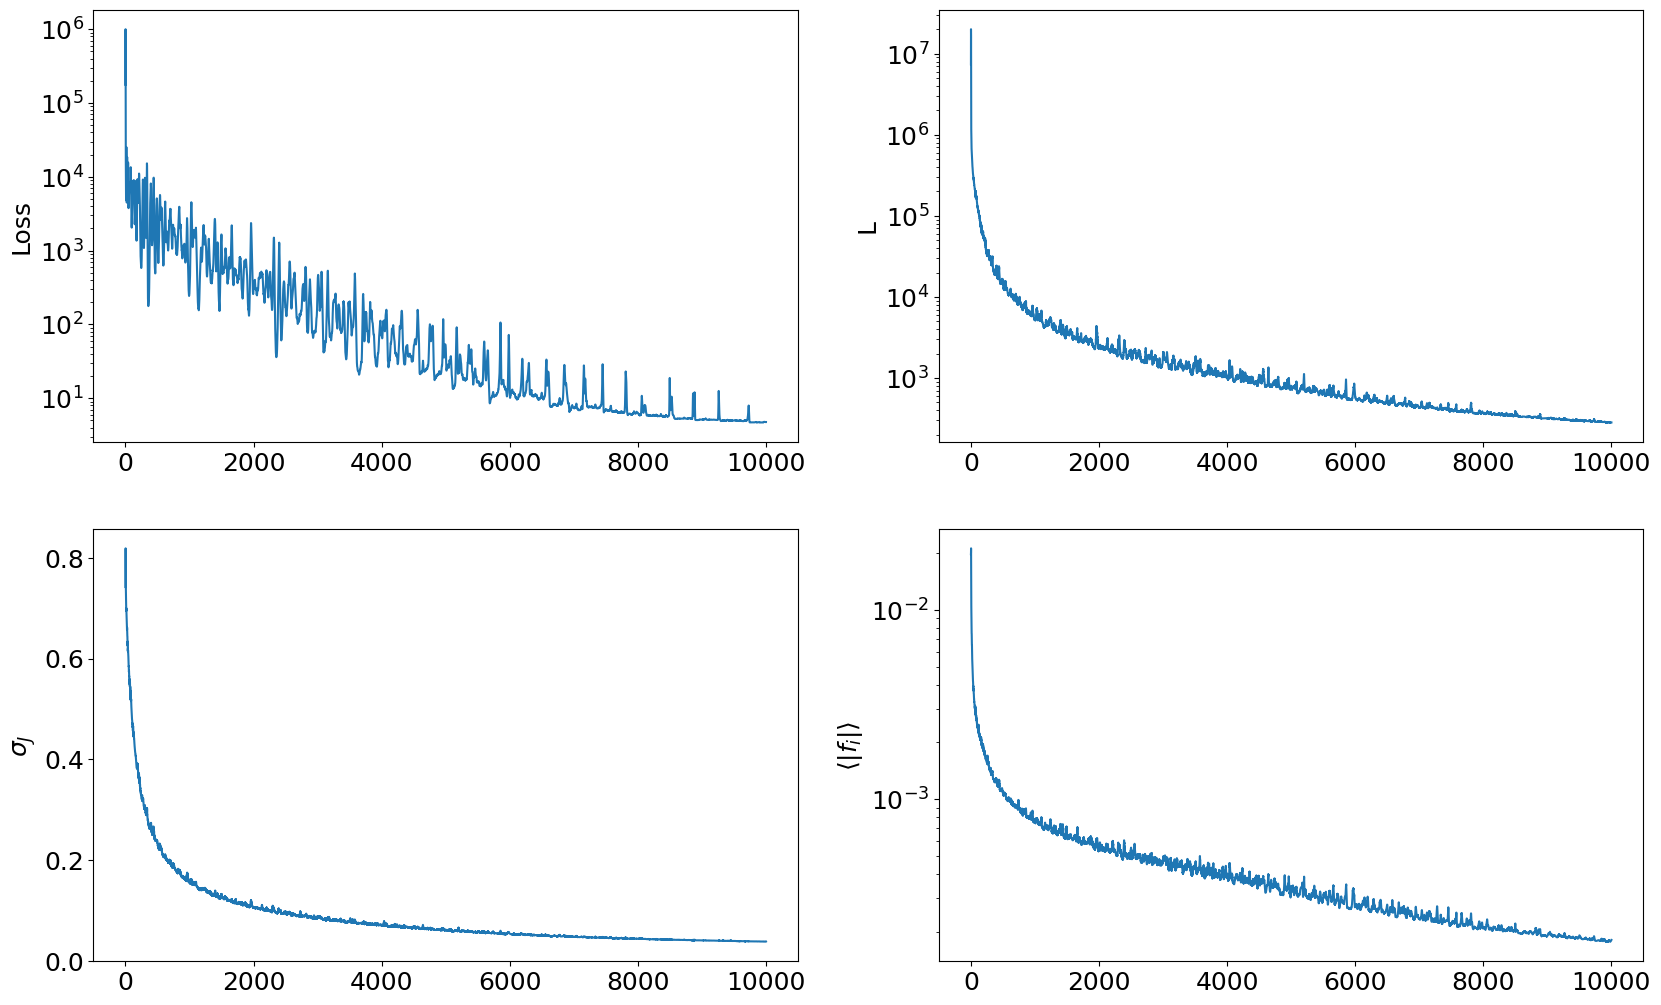

In [28]:
plt.rcParams['font.size'] = 18
plt.figure(figsize=(20,6.18*2))
plt.subplot(221)
plt.plot(model.loss_list)
plt.yscale('log')
plt.ylabel('Loss')

plt.subplot(222)
plt.plot(model.L_list)
plt.yscale('log')
plt.ylabel('L')

plt.subplot(223)
plt.plot(model.sJ_list)
plt.ylabel('$\sigma_J$')

plt.subplot(224)
plt.plot(model.fi_list)
plt.yscale('log')
plt.ylabel(r'$\left<\|f_i\|\right>$')

plt.show()